In [7]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import matplotlib
import texplot
import matplotlib.ticker as mticker
import matplotlib.transforms as mtransforms

import freealg
from freealg import AlgebraicForm
from freealg.distributions import DeformedMarchenkoPastur, CompoundFreePoisson
from freealg.visualization._plot_util import plot_density

plot_dir = './plots'
latex = True

In [2]:
filename = 'deformed_mp'

lam = 0.1
t1 = 2.0
t2 = 5.5
w1 = 0.75

dmp = DeformedMarchenkoPastur(t=[t1, t2], w=[w1, 1-w1], c=lam)
cfp = CompoundFreePoisson(t=[t1, t2], w=[w1, 1-w1], lam=lam)

x = numpy.linspace(-1, 9, 200)
rho_dmp = dmp.density(x)
rho_cfp = cfp.density(x)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/dmp-density.pdf".


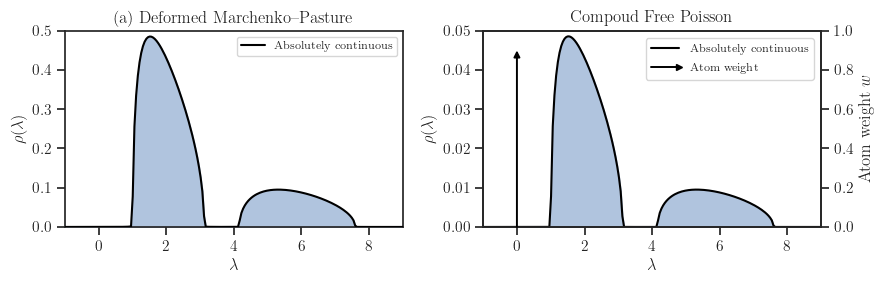

In [14]:
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(9, 3), ncols=2, sharey=False)

    plot_density(x, rho_dmp, ax=ax[0], atoms=None, support=None,
                 label='Absolutely continuous', title=r'(a) Deformed Marchenko--Pasture',
                 log=False, fill_color='lightsteelblue')
    plot_density(x, rho_cfp, ax=ax[1], atoms=[(0, 0.9)], support=None,
                 label='Absolutely continuous', title=r'Compoud Free Poisson', log=False,
                 fill_color='lightsteelblue')

    ax[0].set_ylim([0, 0.5])
    ax[1].set_ylim([0, 0.05])

    for i in range(len(ax)):
        leg = ax[i].get_legend()
        for text in leg.get_texts():
            text.set_fontsize('x-small')

    plt.tight_layout()

    # Zero pad on left, right, and top of canvas
    fig.canvas.draw()
    bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    pad = 0.75 / 72.0
    bbox = mtransforms.Bbox.from_extents(bbox.x0-pad, bbox.y0-pad,
                                         bbox.x1+pad, bbox.y1+pad)

    save_filename = join(plot_dir, 'dmp-density.pdf')
    texplot.show_or_save_plot(plt, default_filename=save_filename,
                              transparent_background=True, dpi=400,
                              bbox_inches=bbox,
                              show_and_save=True, verbose=True)